In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import chi2_contingency
import warnings
warnings.filterwarnings('ignore')

**** ADVANCED EXPLORATORY DATA ANALYSIS ****
Dataset Shape: (400, 15)


1. DATA OVERVIEW
------------------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 15 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   user_id                      400 non-null    object 
 1   age                          400 non-null    int64  
 2   gender                       400 non-null    object 
 3   occupation                   400 non-null    object 
 4   work_mode                    400 non-null    object 
 5   screen_time_hours            400 non-null    float64
 6   work_screen_hours            400 non-null    float64
 7   leisure_screen_hours         400 non-null    float64
 8   sleep_hours                  400 non-null    float64
 9   sleep_quality_1_5            400 non-null    int64  
 10  stress_level_0_10            400 non-null    float64
 11  productivity_0_1

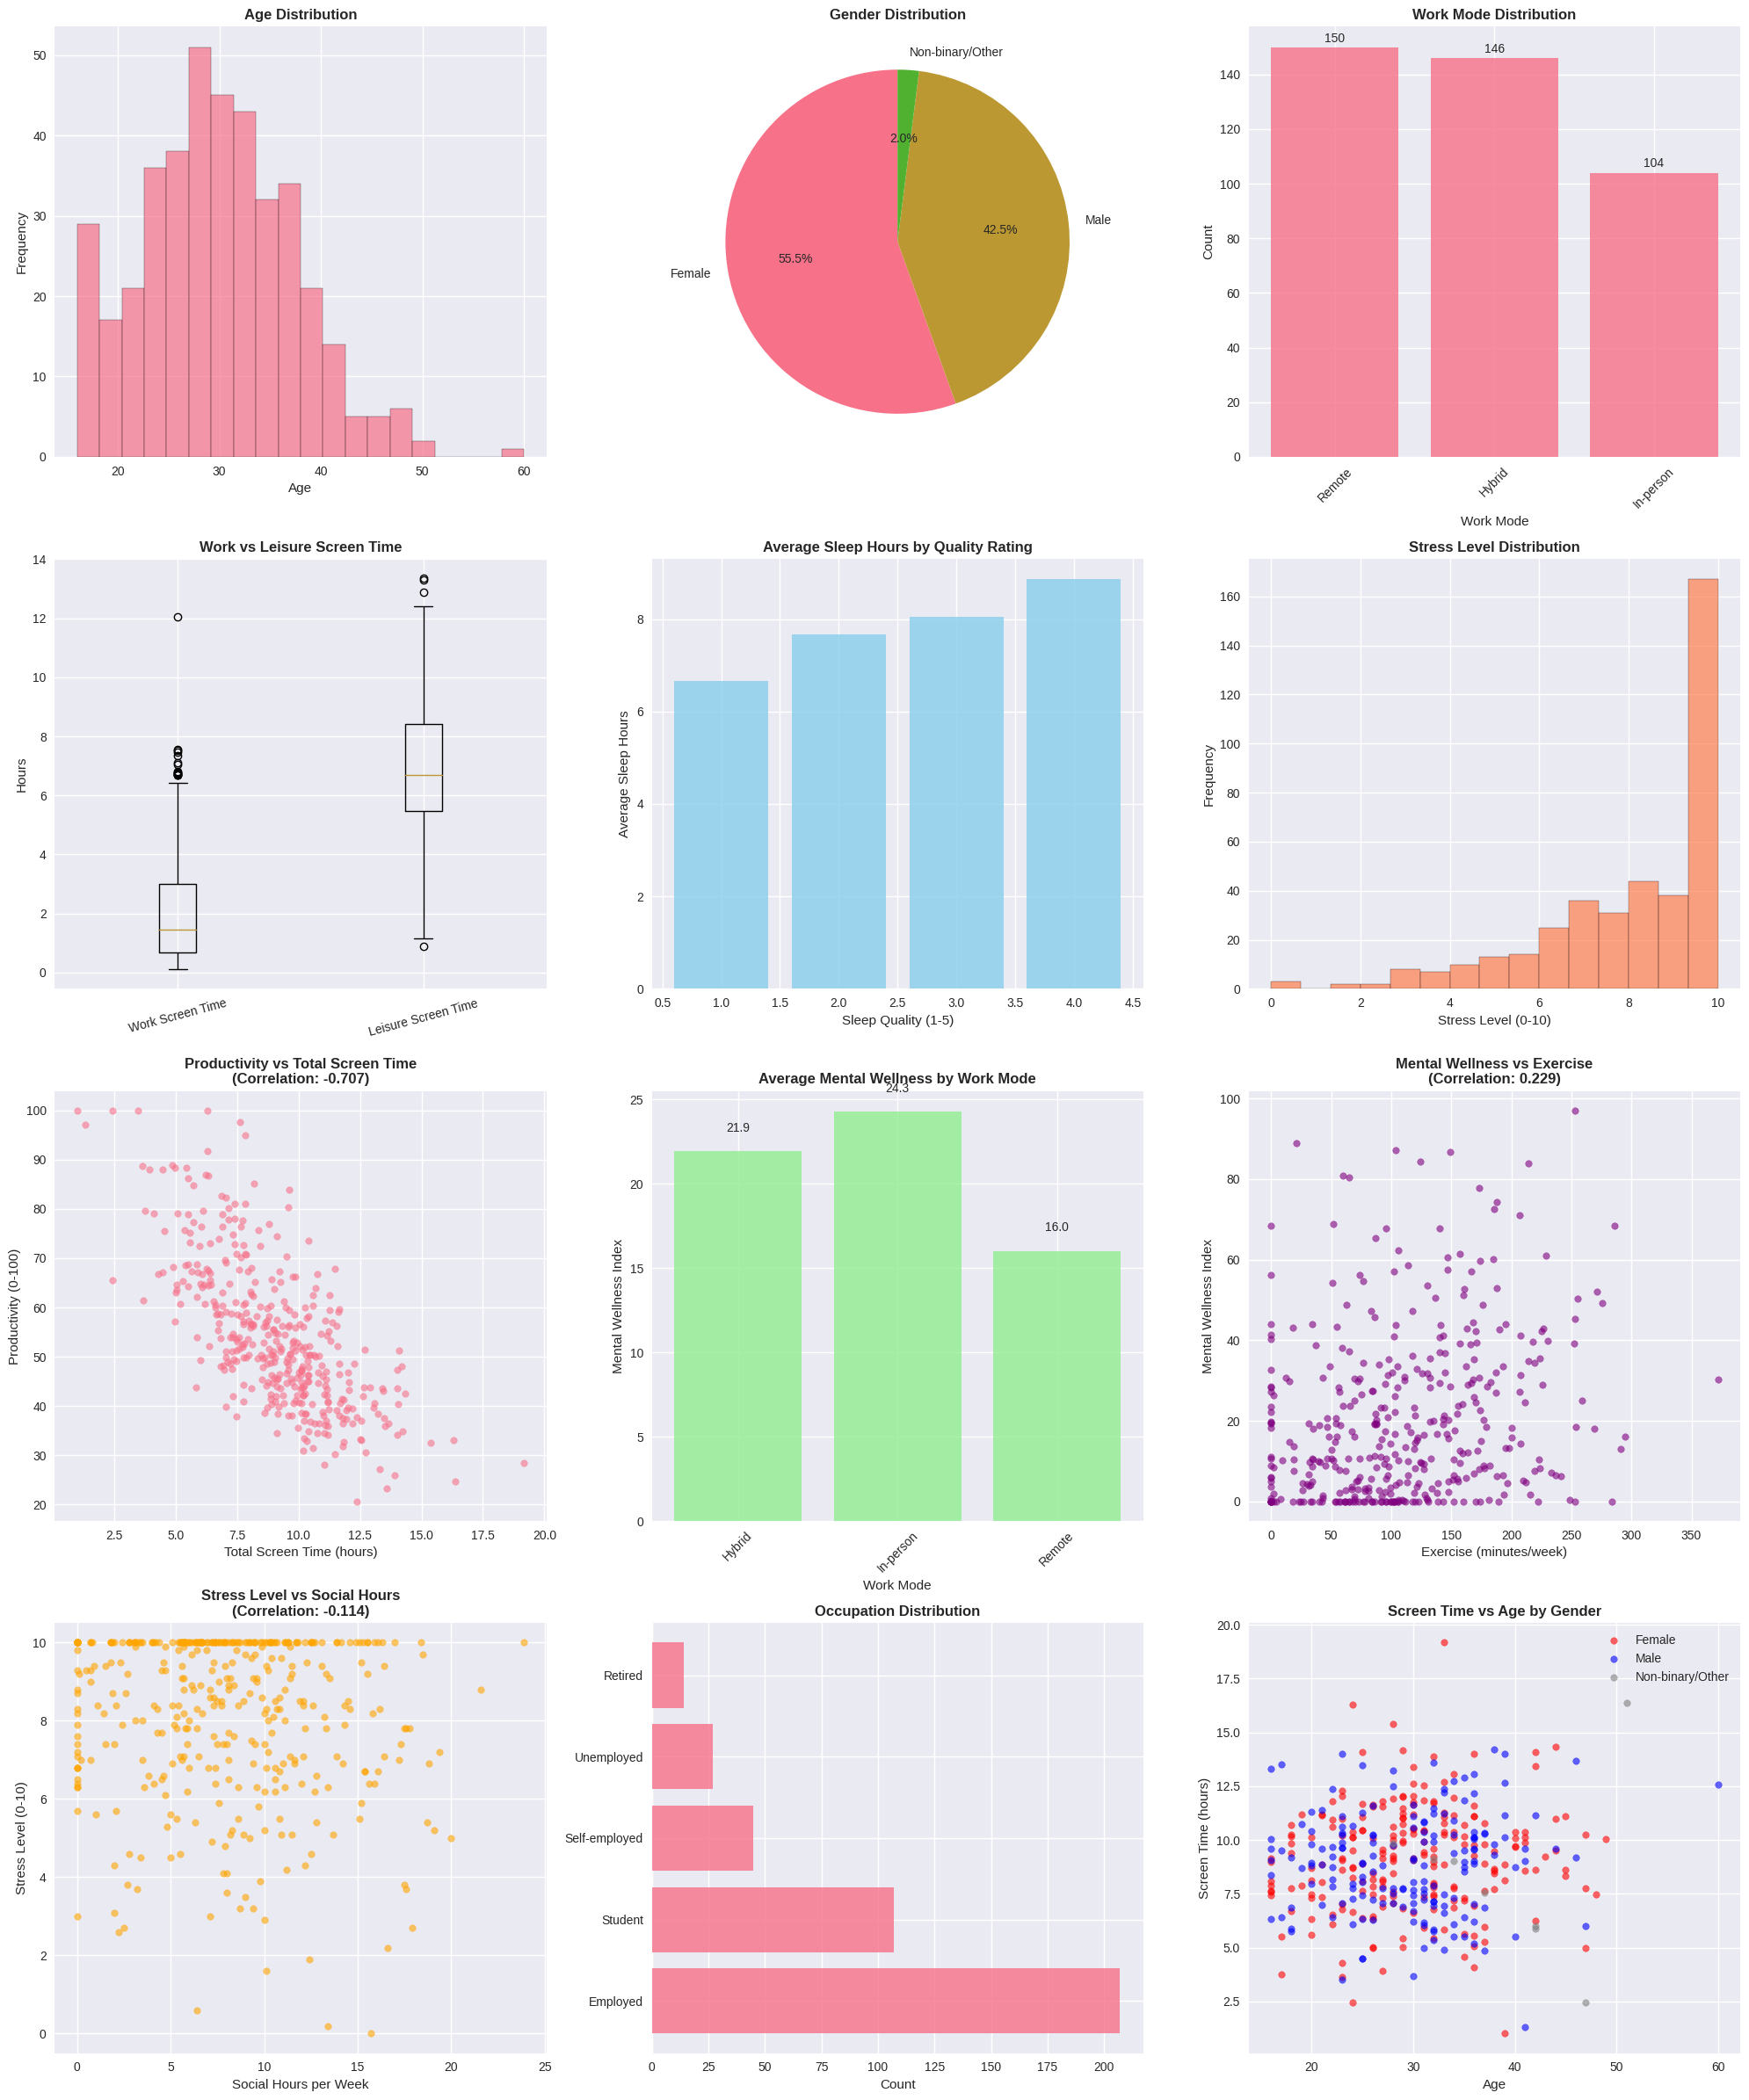

In [2]:
# Set style for better visualizations
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

# Load your data 
df = pd.read_csv('/kaggle/input/screentime-vs-mentalwellness-survey-2025/ScreenTime vs MentalWellness.csv')

# Drop the unnamed column if it exists
if 'Unnamed: 15' in df.columns:
    df = df.drop('Unnamed: 15', axis=1)

print("**** ADVANCED EXPLORATORY DATA ANALYSIS ****")
print("Dataset Shape:", df.shape)
print("\n" + "="*50)

# 1. BASIC DATA OVERVIEW
print("\n1. DATA OVERVIEW")
print("-" * 30)
print(df.info())
print("\nFirst 5 rows:")
print(df.head())

print("\nMissing Values:")
print(df.isnull().sum())


# 2. STATISTICAL SUMMARY
print("\n2. STATISTICAL SUMMARY")
print("-" * 30)
numeric_cols = df.select_dtypes(include=[np.number]).columns
print(df[numeric_cols].describe())

# Create comprehensive visualizations
fig = plt.figure(figsize=(20, 24))

# 3. DISTRIBUTION ANALYSIS
print("\n3. CREATING VISUALIZATIONS...")

# Age distribution
plt.subplot(4, 3, 1)
plt.hist(df['age'], bins=20, alpha=0.7, edgecolor='black')
plt.title('Age Distribution', fontsize=12, fontweight='bold')
plt.xlabel('Age')
plt.ylabel('Frequency')

# Gender distribution
plt.subplot(4, 3, 2)
gender_counts = df['gender'].value_counts()
plt.pie(gender_counts.values, labels=gender_counts.index, autopct='%1.1f%%', startangle=90)
plt.title('Gender Distribution', fontsize=12, fontweight='bold')

# Work mode distribution
plt.subplot(4, 3, 3)
work_mode_counts = df['work_mode'].value_counts()
bars = plt.bar(work_mode_counts.index, work_mode_counts.values, alpha=0.8)
plt.title('Work Mode Distribution', fontsize=12, fontweight='bold')
plt.xlabel('Work Mode')
plt.ylabel('Count')
plt.xticks(rotation=45)
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 1,
             f'{int(height)}', ha='center', va='bottom')

# Screen time analysis
plt.subplot(4, 3, 4)
plt.boxplot([df['work_screen_hours'], df['leisure_screen_hours']], 
            labels=['Work Screen Time', 'Leisure Screen Time'])
plt.title('Work vs Leisure Screen Time', fontsize=12, fontweight='bold')
plt.ylabel('Hours')
plt.xticks(rotation=15)

# Sleep quality vs sleep hours
plt.subplot(4, 3, 5)
sleep_quality_sleep_hours = df.groupby('sleep_quality_1_5')['sleep_hours'].mean()
plt.bar(sleep_quality_sleep_hours.index, sleep_quality_sleep_hours.values, alpha=0.8, color='skyblue')
plt.title('Average Sleep Hours by Quality Rating', fontsize=12, fontweight='bold')
plt.xlabel('Sleep Quality (1-5)')
plt.ylabel('Average Sleep Hours')

# Stress level distribution
plt.subplot(4, 3, 6)
plt.hist(df['stress_level_0_10'], bins=15, alpha=0.7, color='coral', edgecolor='black')
plt.title('Stress Level Distribution', fontsize=12, fontweight='bold')
plt.xlabel('Stress Level (0-10)')
plt.ylabel('Frequency')

# Productivity vs Screen Time
plt.subplot(4, 3, 7)
plt.scatter(df['screen_time_hours'], df['productivity_0_100'], alpha=0.6, s=30)
correlation = df['screen_time_hours'].corr(df['productivity_0_100'])
plt.title(f'Productivity vs Total Screen Time\n(Correlation: {correlation:.3f})', fontsize=12, fontweight='bold')
plt.xlabel('Total Screen Time (hours)')
plt.ylabel('Productivity (0-100)')

# Mental wellness by work mode
plt.subplot(4, 3, 8)
wellness_by_mode = df.groupby('work_mode')['mental_wellness_index_0_100'].mean()
bars = plt.bar(wellness_by_mode.index, wellness_by_mode.values, alpha=0.8, color='lightgreen')
plt.title('Average Mental Wellness by Work Mode', fontsize=12, fontweight='bold')
plt.xlabel('Work Mode')
plt.ylabel('Mental Wellness Index')
plt.xticks(rotation=45)
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 1,
             f'{height:.1f}', ha='center', va='bottom')

# Exercise vs Mental Wellness
plt.subplot(4, 3, 9)
plt.scatter(df['exercise_minutes_per_week'], df['mental_wellness_index_0_100'], 
           alpha=0.6, s=30, color='purple')
correlation = df['exercise_minutes_per_week'].corr(df['mental_wellness_index_0_100'])
plt.title(f'Mental Wellness vs Exercise\n(Correlation: {correlation:.3f})', fontsize=12, fontweight='bold')
plt.xlabel('Exercise (minutes/week)')
plt.ylabel('Mental Wellness Index')

# Social hours vs stress level
plt.subplot(4, 3, 10)
plt.scatter(df['social_hours_per_week'], df['stress_level_0_10'], 
           alpha=0.6, s=30, color='orange')
correlation = df['social_hours_per_week'].corr(df['stress_level_0_10'])
plt.title(f'Stress Level vs Social Hours\n(Correlation: {correlation:.3f})', fontsize=12, fontweight='bold')
plt.xlabel('Social Hours per Week')
plt.ylabel('Stress Level (0-10)')

# Occupation analysis
plt.subplot(4, 3, 11)
occupation_counts = df['occupation'].value_counts()
plt.barh(range(len(occupation_counts)), occupation_counts.values, alpha=0.8)
plt.yticks(range(len(occupation_counts)), occupation_counts.index)
plt.title('Occupation Distribution', fontsize=12, fontweight='bold')
plt.xlabel('Count')

# Age vs Screen Time colored by gender
plt.subplot(4, 3, 12)
colors = {'Male': 'blue', 'Female': 'red', 'Other': 'green'}
for gender in df['gender'].unique():
    gender_data = df[df['gender'] == gender]
    plt.scatter(gender_data['age'], gender_data['screen_time_hours'], 
               alpha=0.6, s=30, label=gender, color=colors.get(gender, 'gray'))
plt.title('Screen Time vs Age by Gender', fontsize=12, fontweight='bold')
plt.xlabel('Age')
plt.ylabel('Screen Time (hours)')
plt.legend()

plt.tight_layout()
plt.show()


4. CORRELATION ANALYSIS
------------------------------


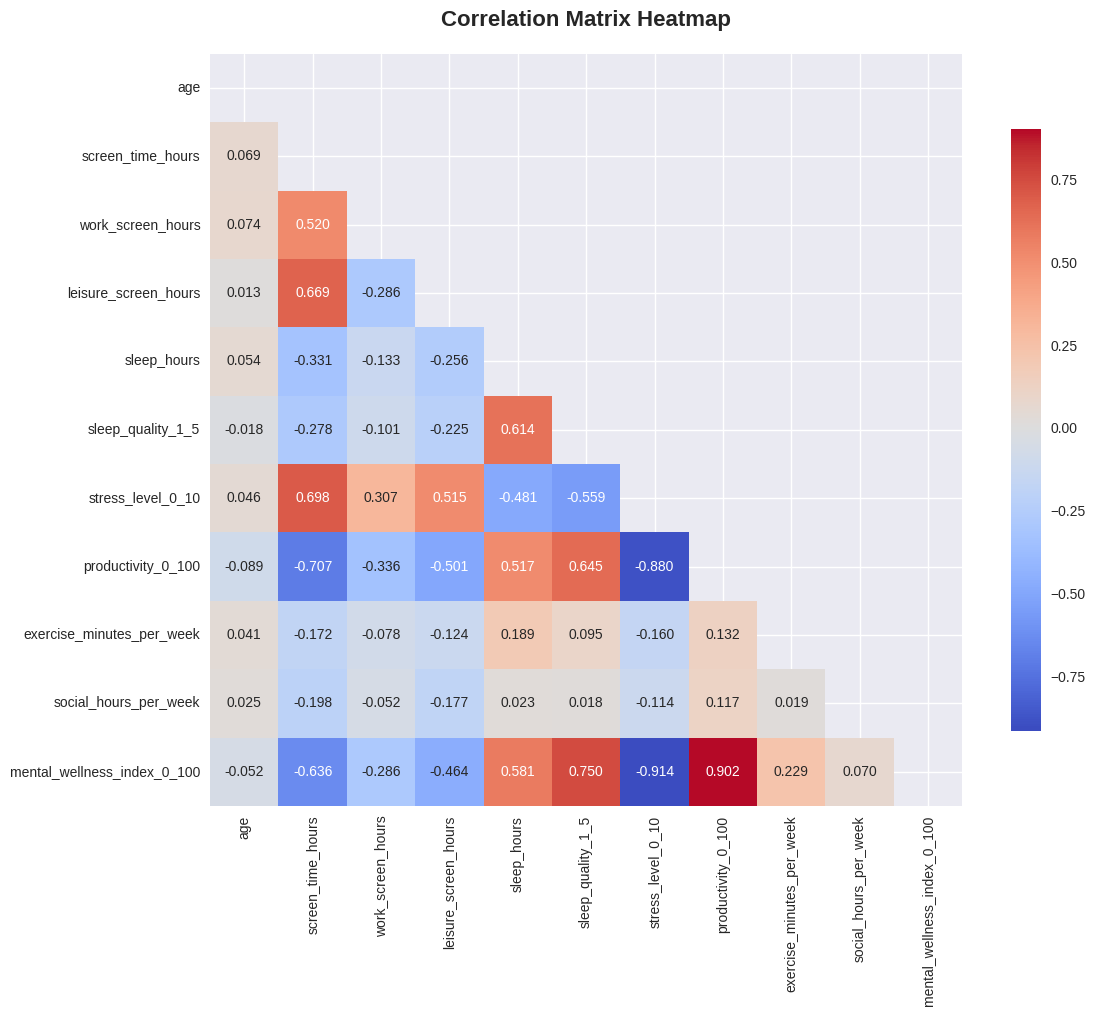

Strongest positive correlations:
stress_level_0_10 <-> mental_wellness_index_0_100: -0.914
productivity_0_100 <-> mental_wellness_index_0_100: 0.902
stress_level_0_10 <-> productivity_0_100: -0.880
sleep_quality_1_5 <-> mental_wellness_index_0_100: 0.750
screen_time_hours <-> productivity_0_100: -0.707
screen_time_hours <-> stress_level_0_10: 0.698
screen_time_hours <-> leisure_screen_hours: 0.669
sleep_quality_1_5 <-> productivity_0_100: 0.645
screen_time_hours <-> mental_wellness_index_0_100: -0.636
sleep_hours <-> sleep_quality_1_5: 0.614


In [3]:
# 4. CORRELATION ANALYSIS
print("\n4. CORRELATION ANALYSIS")
print("-" * 30)

# Calculate correlation matrix for numeric variables
numeric_df = df.select_dtypes(include=[np.number])
correlation_matrix = numeric_df.corr()

# Create correlation heatmap
plt.figure(figsize=(12, 10))
mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))
sns.heatmap(correlation_matrix, mask=mask, annot=True, cmap='coolwarm', center=0,
            square=True, fmt='.3f', cbar_kws={'shrink': 0.8})
plt.title('Correlation Matrix Heatmap', fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

# Print strongest correlations
print("Strongest positive correlations:")
correlation_pairs = []
for i in range(len(correlation_matrix.columns)):
    for j in range(i+1, len(correlation_matrix.columns)):
        corr_val = correlation_matrix.iloc[i, j]
        correlation_pairs.append((correlation_matrix.columns[i], correlation_matrix.columns[j], corr_val))

correlation_pairs.sort(key=lambda x: abs(x[2]), reverse=True)
for var1, var2, corr in correlation_pairs[:10]:
    print(f"{var1} <-> {var2}: {corr:.3f}")


In [4]:
# 5. ADVANCED STATISTICAL ANALYSIS
print("\n5. ADVANCED STATISTICAL ANALYSIS")
print("-" * 30)

# Chi-square test for categorical variables
categorical_vars = ['gender', 'occupation', 'work_mode']
for i, var1 in enumerate(categorical_vars):
    for var2 in categorical_vars[i+1:]:
        contingency_table = pd.crosstab(df[var1], df[var2])
        chi2, p_value, dof, expected = chi2_contingency(contingency_table)
        print(f"Chi-square test {var1} vs {var2}: p-value = {p_value:.4f}")

# ANOVA tests
print("\nANOVA Tests:")
print("Mental Wellness by Work Mode:")
groups = [group['mental_wellness_index_0_100'].values for name, group in df.groupby('work_mode')]
f_stat, p_value = stats.f_oneway(*groups)
print(f"F-statistic: {f_stat:.4f}, p-value: {p_value:.4f}")

print("\nProductivity by Occupation:")
groups = [group['productivity_0_100'].values for name, group in df.groupby('occupation')]
f_stat, p_value = stats.f_oneway(*groups)
print(f"F-statistic: {f_stat:.4f}, p-value: {p_value:.4f}")



5. ADVANCED STATISTICAL ANALYSIS
------------------------------
Chi-square test gender vs occupation: p-value = 0.0218
Chi-square test gender vs work_mode: p-value = 0.7107
Chi-square test occupation vs work_mode: p-value = 0.0000

ANOVA Tests:
Mental Wellness by Work Mode:
F-statistic: 5.9146, p-value: 0.0029

Productivity by Occupation:
F-statistic: 7.5105, p-value: 0.0000


In [5]:
# 6. OUTLIER DETECTION
print("\n6. OUTLIER DETECTION")
print("-" * 30)

def detect_outliers_iqr(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = df[(df[column] < lower_bound) | (df[column] > upper_bound)]
    return outliers

for col in ['screen_time_hours', 'stress_level_0_10', 'productivity_0_100', 'mental_wellness_index_0_100']:
    outliers = detect_outliers_iqr(df, col)
    print(f"{col}: {len(outliers)} outliers ({len(outliers)/len(df)*100:.1f}%)")



6. OUTLIER DETECTION
------------------------------
screen_time_hours: 8 outliers (2.0%)
stress_level_0_10: 6 outliers (1.5%)
productivity_0_100: 7 outliers (1.8%)
mental_wellness_index_0_100: 11 outliers (2.8%)


In [6]:
# 7. INSIGHTS AND PATTERNS
print("\n7. KEY INSIGHTS AND PATTERNS")
print("-" * 30)

# Screen time patterns
print("Screen Time Patterns:")
print(f"Average total screen time: {df['screen_time_hours'].mean():.2f} hours")
print(f"Average work screen time: {df['work_screen_hours'].mean():.2f} hours")
print(f"Average leisure screen time: {df['leisure_screen_hours'].mean():.2f} hours")

# Wellness patterns by work mode
print("\nWellness by Work Mode:")
wellness_by_mode = df.groupby('work_mode').agg({
    'mental_wellness_index_0_100': 'mean',
    'stress_level_0_10': 'mean',
    'productivity_0_100': 'mean'
}).round(2)
print(wellness_by_mode)

# Age group analysis
df['age_group'] = pd.cut(df['age'], bins=[0, 30, 45, 100], labels=['Young', 'Middle', 'Senior'])
print("\nMetrics by Age Group:")
age_analysis = df.groupby('age_group').agg({
    'screen_time_hours': 'mean',
    'mental_wellness_index_0_100': 'mean',
    'productivity_0_100': 'mean'
}).round(2)
print(age_analysis)

print("\n" + "="*50)
print("ANALYSIS COMPLETE IF YOU LIKE PLZ UPVOTE!")
print("="*50)


7. KEY INSIGHTS AND PATTERNS
------------------------------
Screen Time Patterns:
Average total screen time: 9.02 hours
Average work screen time: 2.18 hours
Average leisure screen time: 6.84 hours

Wellness by Work Mode:
           mental_wellness_index_0_100  stress_level_0_10  productivity_0_100
work_mode                                                                    
Hybrid                           21.93               8.00               56.01
In-person                        24.29               7.67               57.88
Remote                           16.02               8.63               50.17

Metrics by Age Group:
           screen_time_hours  mental_wellness_index_0_100  productivity_0_100
age_group                                                                    
Young                   8.98                        20.81               55.00
Middle                  9.07                        20.12               53.73
Senior                  9.16                        1

In [7]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier, GradientBoostingRegressor
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.svm import SVR, SVC
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import mean_squared_error, r2_score, accuracy_score, classification_report, mean_absolute_error
from sklearn.cluster import KMeans
import joblib
import warnings
warnings.filterwarnings('ignore')

print("="*70)
print("OPTIMIZED PREDICTIVE MODELS WITH BEST PERFORMANCE")
print("="*70)

# =============================================================================
# STEP 1: LOAD AND PREPARE DATA
# =============================================================================

print("\n🔧 STEP 1: LOAD YOUR DATA")
print("-" * 40)

df = pd.read_csv('/kaggle/input/screentime-vs-mentalwellness-survey-2025/ScreenTime vs MentalWellness.csv')

# Clean the data
if 'Unnamed: 15' in df.columns:
    df = df.drop('Unnamed: 15', axis=1)

print(f"✅ Data loaded: {df.shape[0]} users, {df.shape[1]} features")

# =============================================================================
# STEP 2: ENHANCED DATA PREPROCESSING
# =============================================================================

print("\n🔄 STEP 2: DATA PREPROCESSING")
print("-" * 40)

class EnhancedDataPreprocessor:
    def __init__(self):
        self.encoders = {}
        self.scaler = StandardScaler()
        self.is_fitted = False
        self.feature_columns = None
    
    def fit_transform(self, df, target_columns=None):
        """Fit preprocessor and transform data"""
        df_processed = df.copy()
        
        # Remove non-predictive columns
        columns_to_remove = ['user_id'] + ([col for col in df_processed.columns if 'Unnamed' in str(col)])
        if target_columns:
            columns_to_remove.extend(target_columns)
        
        for col in columns_to_remove:
            if col in df_processed.columns:
                df_processed = df_processed.drop(col, axis=1)
        
        # Encode categorical variables
        categorical_cols = ['gender', 'occupation', 'work_mode']
        for col in categorical_cols:
            if col in df_processed.columns:
                self.encoders[col] = LabelEncoder()
                df_processed[f'{col}_encoded'] = self.encoders[col].fit_transform(df_processed[col].astype(str))
                df_processed = df_processed.drop(col, axis=1)
        
        # Convert remaining object columns to numeric
        for col in df_processed.columns:
            if df_processed[col].dtype == 'object':
                try:
                    df_processed[col] = pd.to_numeric(df_processed[col], errors='coerce')
                    df_processed[col] = df_processed[col].fillna(df_processed[col].median())
                except:
                    if col not in self.encoders:
                        self.encoders[col] = LabelEncoder()
                        df_processed[col] = self.encoders[col].fit_transform(df_processed[col].astype(str))
        
        # Ensure all columns are numeric
        df_processed = df_processed.select_dtypes(include=[np.number])
        
        # Store feature columns
        self.feature_columns = df_processed.columns.tolist()
        self.is_fitted = True
        
        return df_processed
    
    def transform(self, df):
        """Transform new data using fitted preprocessor"""
        if not self.is_fitted:
            raise ValueError("Preprocessor must be fitted first!")
            
        df_processed = df.copy()
        
        # Remove non-predictive columns
        if 'user_id' in df_processed.columns:
            df_processed = df_processed.drop('user_id', axis=1)
        
        # Apply same categorical encoding
        categorical_cols = ['gender', 'occupation', 'work_mode']
        for col in categorical_cols:
            if col in df_processed.columns and col in self.encoders:
                try:
                    df_processed[f'{col}_encoded'] = self.encoders[col].transform(df_processed[col].astype(str))
                except ValueError:
                    mode_value = self.encoders[col].classes_[0]
                    unseen_mask = ~df_processed[col].astype(str).isin(self.encoders[col].classes_)
                    df_processed.loc[unseen_mask, col] = mode_value
                    df_processed[col] = df_processed[col].fillna(mode_value)
                    df_processed[f'{col}_encoded'] = self.encoders[col].transform(df_processed[col].astype(str))
                df_processed = df_processed.drop(col, axis=1)
        
        # Handle other encoded columns
        for col in list(df_processed.columns):
            if col in self.encoders and col not in categorical_cols:
                try:
                    df_processed[col] = self.encoders[col].transform(df_processed[col].astype(str))
                except ValueError:
                    mode_value = self.encoders[col].classes_[0]
                    unseen_mask = ~df_processed[col].astype(str).isin(self.encoders[col].classes_)
                    df_processed.loc[unseen_mask, col] = mode_value
                    df_processed[col] = self.encoders[col].transform(df_processed[col].astype(str))
        
        # Convert to numeric
        for col in df_processed.columns:
            if df_processed[col].dtype == 'object':
                try:
                    df_processed[col] = pd.to_numeric(df_processed[col], errors='coerce')
                    df_processed[col] = df_processed[col].fillna(df_processed[col].median())
                except:
                    df_processed = df_processed.drop(col, axis=1)
        
        # Ensure same columns as training
        df_processed = df_processed.reindex(columns=self.feature_columns, fill_value=0)
        return df_processed

# =============================================================================
# STEP 3: BEST MODEL SELECTION AND TRAINING
# =============================================================================

print("\n🤖 STEP 3: TRAIN AND EVALUATE BEST MODELS")
print("-" * 40)

class BestModelSelector:
    def __init__(self):
        self.best_regression_model = None
        self.best_classification_model = None
        self.best_regression_score = -np.inf
        self.best_classification_score = -np.inf
        self.scaler = StandardScaler()
        
    def evaluate_regression_models(self, X_train, X_test, y_train, y_test):
        """Evaluate multiple regression models and select the best"""
        
        # Scale features for models that need it
        X_train_scaled = self.scaler.fit_transform(X_train)
        X_test_scaled = self.scaler.transform(X_test)
        
        models = {
            'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42),
            'Gradient Boosting': GradientBoostingRegressor(n_estimators=100, random_state=42),
            'Ridge Regression': Ridge(alpha=1.0),
            'Linear Regression': LinearRegression(),
            'Lasso Regression': Lasso(alpha=1.0)
        }
        
        results = {}
        
        for name, model in models.items():
            print(f"Training {name}...")
            
            # Use scaled data for linear models
            if name in ['Ridge Regression', 'Linear Regression', 'Lasso Regression']:
                model.fit(X_train_scaled, y_train)
                y_pred = model.predict(X_test_scaled)
            else:
                model.fit(X_train, y_train)
                y_pred = model.predict(X_test)
            
            # Calculate metrics
            r2 = r2_score(y_test, y_pred)
            mse = mean_squared_error(y_test, y_pred)
            mae = mean_absolute_error(y_test, y_pred)
            rmse = np.sqrt(mse)
            
            results[name] = {
                'model': model,
                'r2_score': r2,
                'mse': mse,
                'mae': mae,
                'rmse': rmse,
                'predictions': y_pred
            }
            
            print(f"  R² Score: {r2:.4f}")
            print(f"  RMSE: {rmse:.4f}")
            print(f"  MAE: {mae:.4f}")
            
            # Update best model
            if r2 > self.best_regression_score:
                self.best_regression_score = r2
                self.best_regression_model = {
                    'name': name,
                    'model': model,
                    'metrics': results[name],
                    'use_scaled': name in ['Ridge Regression', 'Linear Regression', 'Lasso Regression']
                }
            
            print("-" * 30)
        
        return results
    
    def evaluate_classification_models(self, X_train, X_test, y_train, y_test):
        """Evaluate multiple classification models and select the best"""
        
        # Scale features
        X_train_scaled = self.scaler.transform(X_train)  # Already fitted from regression
        X_test_scaled = self.scaler.transform(X_test)
        
        models = {
            'Random Forest Classifier': RandomForestClassifier(n_estimators=100, random_state=42),
            'SVM Classifier': SVC(random_state=42),
        }
        
        results = {}
        
        for name, model in models.items():
            print(f"Training {name}...")
            
            # Use scaled data for SVM
            if name == 'SVM Classifier':
                model.fit(X_train_scaled, y_train)
                y_pred = model.predict(X_test_scaled)
            else:
                model.fit(X_train, y_train)
                y_pred = model.predict(X_test)
            
            # Calculate metrics
            accuracy = accuracy_score(y_test, y_pred)
            
            results[name] = {
                'model': model,
                'accuracy': accuracy,
                'predictions': y_pred
            }
            
            print(f"  Accuracy: {accuracy:.4f}")
            print(f"  Classification Report:")
            print(classification_report(y_test, y_pred, target_names=['Low', 'Medium', 'High']))
            
            # Update best model
            if accuracy > self.best_classification_score:
                self.best_classification_score = accuracy
                self.best_classification_model = {
                    'name': name,
                    'model': model,
                    'metrics': results[name],
                    'use_scaled': name == 'SVM Classifier'
                }
            
            print("-" * 30)
        
        return results

class EnhancedUserSegmentation:
    def __init__(self, n_clusters=4):
        self.n_clusters = n_clusters
        self.model = KMeans(n_clusters=n_clusters, random_state=42)
        self.scaler = StandardScaler()
        self.cluster_profiles = None
        self.inertia_score = None
        self.silhouette_score = None
        self.is_fitted = False
    
    def fit_and_evaluate(self, X):
        """Fit clustering model and evaluate performance"""
        from sklearn.metrics import silhouette_score
        
        # Select relevant features for clustering
        cluster_features = ['age', 'screen_time_hours', 'sleep_hours', 'stress_level_0_10']
        available_features = [col for col in cluster_features if col in X.columns]
        
        if len(available_features) < 2:
            print("⚠️ Not enough features for clustering")
            return None
            
        X_cluster = X[available_features]
        
        # Scale and fit
        X_scaled = self.scaler.fit_transform(X_cluster)
        clusters = self.model.fit_predict(X_scaled)
        
        # Calculate metrics
        self.inertia_score = self.model.inertia_
        self.silhouette_score = silhouette_score(X_scaled, clusters)
        
        # Create cluster profiles
        X_with_clusters = X_cluster.copy()
        X_with_clusters['cluster'] = clusters
        self.cluster_profiles = X_with_clusters.groupby('cluster').agg(['mean', 'std']).round(2)
        
        self.is_fitted = True
        
        print(f"✅ Clustering completed - {self.n_clusters} clusters")
        print(f"Inertia Score: {self.inertia_score:.2f}")
        print(f"Silhouette Score: {self.silhouette_score:.4f}")
        print("\nCluster Profiles:")
        print(self.cluster_profiles)
        
        return clusters

# Initialize preprocessing
preprocessor = EnhancedDataPreprocessor()

# Find target columns
target_columns = []
if 'mental_wellness_index_0_100' in df.columns:
    target_columns.append('mental_wellness_index_0_100')
    wellness_target = 'mental_wellness_index_0_100'
else:
    wellness_cols = [col for col in df.columns if 'wellness' in col.lower() or 'mental' in col.lower()]
    if wellness_cols:
        wellness_target = wellness_cols[0]
        target_columns.append(wellness_target)
    else:
        raise ValueError("No mental wellness target found!")

productivity_cols = [col for col in df.columns if 'productivity' in col.lower()]
productivity_target = None
if productivity_cols:
    productivity_target = productivity_cols[0]
    target_columns.append(productivity_target)

print(f"Target columns identified: {target_columns}")

# Preprocess data
X = preprocessor.fit_transform(df, target_columns)
y_wellness = df[wellness_target]

print(f"✅ Preprocessing completed")
print(f"Features: {X.shape[1]}")
print(f"Samples: {X.shape[0]}")

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y_wellness, test_size=0.2, random_state=42)

print(f"Training set: {X_train.shape}")
print(f"Test set: {X_test.shape}")

# =============================================================================
# STEP 4: TRAIN AND EVALUATE BEST MODELS
# =============================================================================

print("\n🏆 STEP 4: MODEL TRAINING AND EVALUATION")
print("-" * 50)

# Initialize model selector
model_selector = BestModelSelector()

print("🔍 MENTAL WELLNESS REGRESSION MODELS:")
print("=" * 50)
regression_results = model_selector.evaluate_regression_models(X_train, X_test, y_train, y_test)

print(f"\n🏅 BEST REGRESSION MODEL: {model_selector.best_regression_model['name']}")
print(f"Best R² Score: {model_selector.best_regression_score:.4f}")

# Train productivity classification if available
if productivity_target:
    print("\n🔍 PRODUCTIVITY CLASSIFICATION MODELS:")
    print("=" * 50)
    
    # Create productivity categories
    y_productivity = df[productivity_target]
    y_prod_categories = pd.cut(y_productivity, bins=[0, 60, 80, 100], labels=['Low', 'Medium', 'High'])
    
    # Remove NaN values
    mask = ~y_prod_categories.isna()
    X_prod = X[mask]
    y_prod_clean = y_prod_categories[mask]
    
    # Split productivity data
    X_prod_train, X_prod_test, y_prod_train, y_prod_test = train_test_split(
        X_prod, y_prod_clean, test_size=0.2, random_state=42
    )
    
    classification_results = model_selector.evaluate_classification_models(
        X_prod_train, X_prod_test, y_prod_train, y_prod_test
    )
    
    print(f"\n🏅 BEST CLASSIFICATION MODEL: {model_selector.best_classification_model['name']}")
    print(f"Best Accuracy: {model_selector.best_classification_score:.4f}")

# Train clustering model
print("\n🔍 USER SEGMENTATION:")
print("=" * 50)
segmentation = EnhancedUserSegmentation()
clusters = segmentation.fit_and_evaluate(X)

# =============================================================================
# STEP 5: SAVE BEST MODELS
# =============================================================================

print("\n💾 STEP 5: SAVE BEST MODELS")
print("-" * 40)

# Save best models
joblib.dump(model_selector.best_regression_model, 'best_wellness_model.joblib')
joblib.dump(preprocessor, 'enhanced_preprocessor.joblib')
joblib.dump(segmentation, 'enhanced_segmentation.joblib')

if productivity_target and model_selector.best_classification_model:
    joblib.dump(model_selector.best_classification_model, 'best_productivity_model.joblib')

print("✅ Best models saved:")
print("  • best_wellness_model.joblib")
print("  • enhanced_preprocessor.joblib")
print("  • enhanced_segmentation.joblib")
if productivity_target and model_selector.best_classification_model:
    print("  • best_productivity_model.joblib")

# =============================================================================
# STEP 6: FINAL PERFORMANCE SUMMARY
# =============================================================================

print("\n📊 FINAL PERFORMANCE SUMMARY")
print("=" * 70)

print(f"🎯 MENTAL WELLNESS PREDICTION:")
print(f"   Best Model: {model_selector.best_regression_model['name']}")
print(f"   R² Score: {model_selector.best_regression_score:.4f}")
print(f"   RMSE: {model_selector.best_regression_model['metrics']['rmse']:.4f}")
print(f"   MAE: {model_selector.best_regression_model['metrics']['mae']:.4f}")

if productivity_target and model_selector.best_classification_model:
    print(f"\n🎯 PRODUCTIVITY CLASSIFICATION:")
    print(f"   Best Model: {model_selector.best_classification_model['name']}")
    print(f"   Accuracy: {model_selector.best_classification_score:.4f}")

print(f"\n🎯 USER SEGMENTATION:")
print(f"   Clusters: {segmentation.n_clusters}")
print(f"   Silhouette Score: {segmentation.silhouette_score:.4f}")

print(f"\n🎯 FEATURE IMPORTANCE (Top 5):")
if hasattr(model_selector.best_regression_model['model'], 'feature_importances_'):
    importance_df = pd.DataFrame({
        'feature': preprocessor.feature_columns,
        'importance': model_selector.best_regression_model['model'].feature_importances_
    }).sort_values('importance', ascending=False)
    
    print(importance_df.head().to_string(index=False))

print(f"\n{'='*70}")
print("✅ OPTIMIZED PREDICTIVE MODELS COMPLETE!")
print("🏆 Best performing models selected and saved!")
print("📈 Ready for deployment and real-world use!")
print("="*70)

OPTIMIZED PREDICTIVE MODELS WITH BEST PERFORMANCE

🔧 STEP 1: LOAD YOUR DATA
----------------------------------------
✅ Data loaded: 400 users, 15 features

🔄 STEP 2: DATA PREPROCESSING
----------------------------------------

🤖 STEP 3: TRAIN AND EVALUATE BEST MODELS
----------------------------------------
Target columns identified: ['mental_wellness_index_0_100', 'productivity_0_100']
✅ Preprocessing completed
Features: 12
Samples: 400
Training set: (320, 12)
Test set: (80, 12)

🏆 STEP 4: MODEL TRAINING AND EVALUATION
--------------------------------------------------
🔍 MENTAL WELLNESS REGRESSION MODELS:
Training Random Forest...
  R² Score: 0.9102
  RMSE: 5.9586
  MAE: 4.6617
------------------------------
Training Gradient Boosting...
  R² Score: 0.9050
  RMSE: 6.1299
  MAE: 4.7956
------------------------------
Training Ridge Regression...
  R² Score: 0.9196
  RMSE: 5.6397
  MAE: 4.2591
------------------------------
Training Linear Regression...
  R² Score: 0.9197
  RMSE: 5.6345
